In [2]:
import os
print(os.getcwd())
print(os.path.exists("electricdss-tst/Version8/Distrib/IEEETestCases/13Bus/IEEE13Nodeckt.dss"))

C:\Users\mathe\Documents\projeto_icc2027
True


In [3]:
import os
os.chdir("C:/Users/mathe/Documents/projeto_icc2027")
print(os.getcwd())

C:\Users\mathe\Documents\projeto_icc2027


In [4]:
import opendssdirect as dss

dss.Text.Command("Clear")
dss.Text.Command("Compile [electricdss-tst/Version8/Distrib/IEEETestCases/13Bus/IEEE13Nodeckt.dss]")
dss.Solution.Solve()

print("Circuit loaded:", dss.Circuit.Name())
print("Number of buses:", len(dss.Circuit.AllBusNames()))
print("Converged:", dss.Solution.Converged())

Circuit loaded: ieee13nodeckt
Number of buses: 16
Converged: True


In [5]:
import pandas as pd

data = []
for bus in dss.Circuit.AllBusNames():
    dss.Circuit.SetActiveBus(bus)
    voltages = dss.Bus.puVmagAngle()
    data.append({
        "bus": bus,
        "voltage_pu": voltages[0] if len(voltages) > 0 else None,
        "angle": voltages[1] if len(voltages) > 1 else None,
        "distance_km": dss.Bus.Distance()
    })

table = pd.DataFrame(data)
table.to_csv("base_scenario.csv", index=False)
print(table)

          bus  voltage_pu       angle  distance_km
0   sourcebus    0.999974   29.992739          0.0
1         650    0.999911   -0.011139          0.0
2        rg60    1.056033   -0.013087          0.0
3         633    1.011301   -2.594629          0.0
4         634    0.987160   -3.279911          0.0
5         671    0.982797   -5.373770          0.0
6         645    1.019729 -121.940137          0.0
7         646    1.018013 -122.015761          0.0
8         692    0.982797   -5.373770          0.0
9         675    0.976273   -5.622749          0.0
10        611    0.960843  115.738202          0.0
11        652    0.975334   -5.322388          0.0
12        670    1.004025   -3.455843          0.0
13        632    1.014343   -2.529344          0.0
14        680    0.982797   -5.373770          0.0
15        684    0.980873   -5.397044          0.0


In [10]:
import networkx as nx

FT_TO_KM = 0.0003048

G = nx.Graph()
for line in dss.Lines.AllNames():
    dss.Lines.Name(line)
    bus1 = dss.Lines.Bus1().split(".")[0]
    bus2 = dss.Lines.Bus2().split(".")[0]
    length_ft = dss.Lines.Length()
    length_km = length_ft * FT_TO_KM
    G.add_edge(bus1, bus2, weight=length_km)

substation = "rg60"
distances = nx.single_source_dijkstra_path_length(G, substation, weight="weight")

for bus, dist in distances.items():
    print(bus, ":", round(dist, 4), "km")

rg60 : 0 km
632 : 0.6096 km
633 : 0.762 km
645 : 0.762 km
670 : 0.8129 km
646 : 0.8534 km
671 : 1.2192 km
692 : 1.2192 km
684 : 1.3106 km
675 : 1.3716 km
611 : 1.4021 km
680 : 1.524 km
652 : 1.5545 km


In [11]:
distance_df = pd.DataFrame(list(distances.items()), columns=["bus", "distance_km"])
table_full = table.drop(columns=["distance_km"]).merge(distance_df, on="bus", how="left")
table_full.to_csv("base_scenario.csv", index=False)
print(table_full)

          bus  voltage_pu       angle  distance_km
0   sourcebus    0.999974   29.992739          NaN
1         650    0.999911   -0.011139          NaN
2        rg60    1.056033   -0.013087     0.000000
3         633    1.011301   -2.594629     0.762000
4         634    0.987160   -3.279911          NaN
5         671    0.982797   -5.373770     1.219200
6         645    1.019729 -121.940137     0.762000
7         646    1.018013 -122.015761     0.853440
8         692    0.982797   -5.373770     1.219200
9         675    0.976273   -5.622749     1.371600
10        611    0.960843  115.738202     1.402080
11        652    0.975334   -5.322388     1.554480
12        670    1.004025   -3.455843     0.812902
13        632    1.014343   -2.529344     0.609600
14        680    0.982797   -5.373770     1.524000
15        684    0.980873   -5.397044     1.310640


In [15]:
import numpy as np

a0 = 0.0
a1 = 7.8e-10
k = 1.0
vp = 2.0e5

def channel_transfer_function(freqs, paths):
    H = np.zeros(len(freqs), dtype=complex)
    for weight, dist_km in paths:
        attenuation = np.exp(-(a0 + a1 * freqs**k) * dist_km)
        phase = np.exp(-1j * 2 * np.pi * freqs * dist_km / vp)
        H += weight * attenuation * phase
    return H

In [16]:
def generate_paths(main_distance_km):
    paths = [
        (1.0, main_distance_km),
        (0.5, main_distance_km * 1.2),
        (0.25, main_distance_km * 1.5),
    ]
    return paths

In [17]:
freqs = np.linspace(1e3, 500e3, 200)

channel_results = {}
for _, row in table_full.dropna(subset=["distance_km"]).iterrows():
    bus = row["bus"]
    dist = row["distance_km"]
    paths = generate_paths(dist)
    H = channel_transfer_function(freqs, paths)
    channel_results[bus] = H

print("Buses processed:", list(channel_results.keys()))

Buses processed: ['rg60', '633', '671', '645', '646', '692', '675', '611', '652', '670', '632', '680', '684']


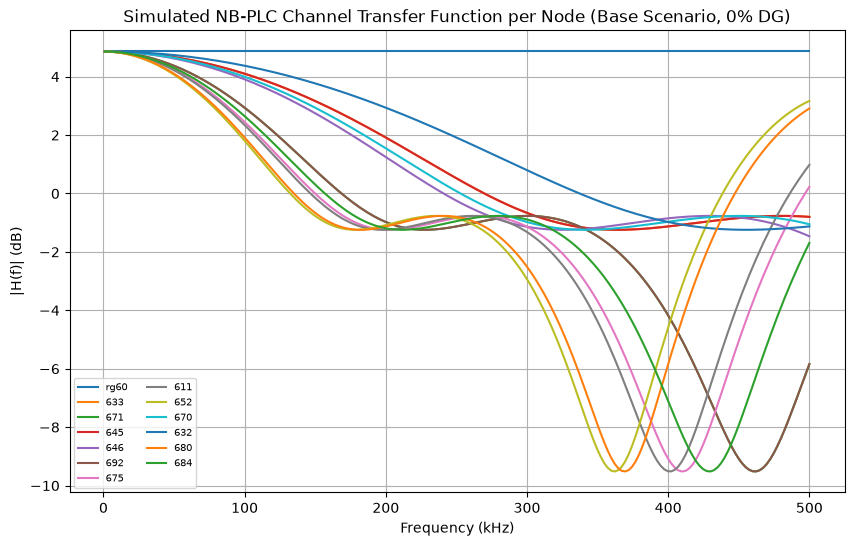

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for bus, H in channel_results.items():
    plt.plot(freqs / 1e3, 20 * np.log10(np.abs(H)), label=bus)

plt.xlabel("Frequency (kHz)")
plt.ylabel("|H(f)| (dB)")
plt.title("Simulated NB-PLC Channel Transfer Function per Node (Base Scenario, 0% DG)")
plt.legend(fontsize=7, ncol=2)
plt.grid(True)
plt.savefig("ctf_base_scenario.png", dpi=300)
plt.show()

In [20]:
os.chdir("C:/Users/mathe/Documents/projeto_icc2027")
dss.Text.Command("Compile [electricdss-tst/Version8/Distrib/IEEETestCases/13Bus/IEEE13Nodeckt.dss]")

total_load_kw = 0
for load in dss.Loads.AllNames():
    dss.Loads.Name(load)
    total_load_kw += dss.Loads.kW()

print("Total feeder load (kW):", total_load_kw)

Total feeder load (kW): 3466.0


In [24]:
pv_buses = ["671", "675", "692", "633"]

In [25]:
def run_dg_scenario(penetration_pct):
    os.chdir("C:/Users/mathe/Documents/projeto_icc2027")
    dss.Text.Command("Clear")
    dss.Text.Command("Compile [electricdss-tst/Version8/Distrib/IEEETestCases/13Bus/IEEE13Nodeckt.dss]")

    if penetration_pct > 0:
        total_pv_kw = total_load_kw * (penetration_pct / 100)
        pv_kw_each = total_pv_kw / len(pv_buses)

        for bus in pv_buses:
            dss.Text.Command(
                f"New PVSystem.PV_{bus} Bus1={bus} Phases=3 kV=4.16 "
                f"kVA={pv_kw_each} Pmpp={pv_kw_each} irradiance=1"
            )

    dss.Solution.Solve()

    data = []
    for b in dss.Circuit.AllBusNames():
        dss.Circuit.SetActiveBus(b)
        v = dss.Bus.puVmagAngle()
        data.append({
            "bus": b,
            "voltage_pu": v[0] if len(v) > 0 else None,
            "angle": v[1] if len(v) > 1 else None,
        })

    df = pd.DataFrame(data)
    df["penetration_pct"] = penetration_pct
    return df

In [26]:
scenarios = [0, 20, 40, 60]
all_scenarios = []

for p in scenarios:
    df = run_dg_scenario(p)
    all_scenarios.append(df)
    print(f"Scenario {p}% DG solved. Converged:", dss.Solution.Converged())

all_scenarios_df = pd.concat(all_scenarios, ignore_index=True)
all_scenarios_df.to_csv("all_dg_scenarios.csv", index=False)
print(all_scenarios_df.head(20))

Scenario 0% DG solved. Converged: True
Scenario 20% DG solved. Converged: True
Scenario 40% DG solved. Converged: True
Scenario 60% DG solved. Converged: True
          bus  voltage_pu       angle  penetration_pct
0   sourcebus    0.999974   29.992739                0
1         650    0.999911   -0.011139                0
2        rg60    1.056033   -0.013087                0
3         633    1.011301   -2.594629                0
4         634    0.987160   -3.279911                0
5         671    0.982797   -5.373770                0
6         645    1.019729 -121.940137                0
7         646    1.018013 -122.015761                0
8         692    0.982797   -5.373770                0
9         675    0.976273   -5.622749                0
10        611    0.960843  115.738202                0
11        652    0.975334   -5.322388                0
12        670    1.004025   -3.455843                0
13        632    1.014343   -2.529344                0
14        680   

In [27]:
all_scenarios_df = all_scenarios_df.merge(
    distance_df, on="bus", how="left"
)
all_scenarios_df.to_csv("all_dg_scenarios.csv", index=False)
print(all_scenarios_df.dropna(subset=["distance_km"]).head(20))

     bus  voltage_pu       angle  penetration_pct  distance_km
2   rg60    1.056033   -0.013087                0     0.000000
3    633    1.011301   -2.594629                0     0.762000
5    671    0.982797   -5.373770                0     1.219200
6    645    1.019729 -121.940137                0     0.762000
7    646    1.018013 -122.015761                0     0.853440
8    692    0.982797   -5.373770                0     1.219200
9    675    0.976273   -5.622749                0     1.371600
10   611    0.960843  115.738202                0     1.402080
11   652    0.975334   -5.322388                0     1.554480
12   670    1.004025   -3.455843                0     0.812902
13   632    1.014343   -2.529344                0     0.609600
14   680    0.982797   -5.373770                0     1.524000
15   684    0.980873   -5.397044                0     1.310640
18  rg60    1.056070   -0.009877               20     0.000000
19   633    1.016995   -2.074495               20     0

In [28]:
def channel_with_voltage_perturbation(freqs, dist_km, voltage_pu):
    """
    Adds a small perturbation to path weights based on voltage deviation
    from nominal (1.0 pu), simulating how DG-driven voltage changes
    affect the PLC channel's multipath weights.
    """
    voltage_factor = voltage_pu  # deviation from 1.0 acts as a weight scaler
    paths = [
        (1.0 * voltage_factor, dist_km),
        (0.5 * voltage_factor, dist_km * 1.2),
        (0.25 * voltage_factor, dist_km * 1.5),
    ]
    return channel_transfer_function(freqs, paths)

all_channel_results = {}
valid_rows = all_scenarios_df.dropna(subset=["distance_km"])

for _, row in valid_rows.iterrows():
    key = (row["bus"], row["penetration_pct"])
    H = channel_with_voltage_perturbation(freqs, row["distance_km"], row["voltage_pu"])
    all_channel_results[key] = H

print("Total channel curves computed:", len(all_channel_results))

Total channel curves computed: 52


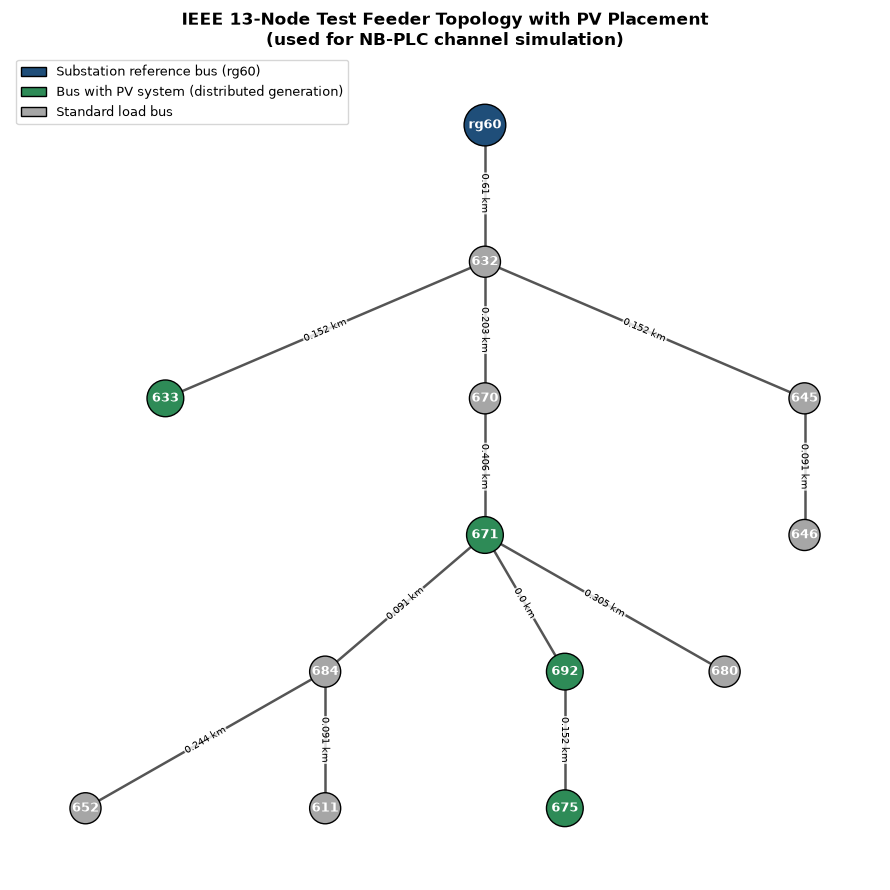

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Manually defined layout approximating the standard IEEE 13-bus feeder diagram.
# Coordinates are illustrative (not to scale), chosen to reproduce the well known
# tree-like shape of the IEEE 13-node test feeder.
pos = {
    "rg60": (0, 10),
    "632":  (0, 8),
    "633":  (-2, 6),
    "634":  (-2, 4),
    "645":  (2, 6),
    "646":  (2, 4),
    "670":  (0, 6),
    "671":  (0, 4),
    "684":  (-1, 2),
    "611":  (-1, 0),
    "652":  (-2.5, 0),
    "680":  (1.5, 2),
    "692":  (0.5, 2),
    "675":  (0.5, 0),
}

# Build a fresh graph including all lines (for drawing purposes)
G_plot = nx.Graph()
for line in dss.Lines.AllNames():
    dss.Lines.Name(line)
    b1 = dss.Lines.Bus1().split(".")[0]
    b2 = dss.Lines.Bus2().split(".")[0]
    length_km = dss.Lines.Length() * FT_TO_KM
    G_plot.add_edge(b1, b2, weight=round(length_km, 3))

pv_buses_set = set(pv_buses)
substation_bus = "rg60"

node_colors = []
node_sizes = []
for node in G_plot.nodes():
    if node == substation_bus:
        node_colors.append("#1f4e79")
        node_sizes.append(900)
    elif node in pv_buses_set:
        node_colors.append("#2e8b57")
        node_sizes.append(700)
    else:
        node_colors.append("#a6a6a6")
        node_sizes.append(500)

fig, ax = plt.subplots(figsize=(9, 9))

nx.draw_networkx_edges(G_plot, pos, ax=ax, edge_color="#555555", width=1.8)
nx.draw_networkx_nodes(G_plot, pos, ax=ax, node_color=node_colors,
                        node_size=node_sizes, edgecolors="black", linewidths=1.0)
nx.draw_networkx_labels(G_plot, pos, ax=ax, font_size=9, font_weight="bold",
                         font_color="white")

edge_labels = nx.get_edge_attributes(G_plot, "weight")
edge_labels = {k: f"{v} km" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G_plot, pos, edge_labels=edge_labels, ax=ax,
                              font_size=7, label_pos=0.5,
                              bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))

legend_elements = [
    mpatches.Patch(facecolor="#1f4e79", edgecolor="black", label="Substation reference bus (rg60)"),
    mpatches.Patch(facecolor="#2e8b57", edgecolor="black", label="Bus with PV system (distributed generation)"),
    mpatches.Patch(facecolor="#a6a6a6", edgecolor="black", label="Standard load bus"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9, frameon=True)

ax.set_title("IEEE 13-Node Test Feeder Topology with PV Placement\n(used for NB-PLC channel simulation)",
              fontsize=12, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig("feeder_topology_pv.png", dpi=300, bbox_inches="tight")
plt.show()